# **SPECTRA testing notebook**

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import argparse
import yaml
import pickle
import torch
import networkx as nx
import scanpy as sc
import numpy as np
import pandas as pd
import warnings
import os
import anndata as ad

ad.settings.allow_write_nullable_strings = True

# Suppress annoying warnings for a clean console
warnings.filterwarnings("ignore")

In [3]:
# torch device setting
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.version.cuda)
    print(torch.cuda.get_device_name())
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

12.1
Tesla V100-SXM2-32GB
Using device: cuda


In [4]:
from spectra.utils import set_seed
from spectra.data import data_preprocessing, build_model_dataloaders_perts_split, compute_weights
from spectra.model import SPECTRA

### **Load config file**

In [5]:
config_path = '../configs/vcc_config_newsweep.yaml'

with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
print(yaml.dump(config, indent=2, sort_keys=False, default_flow_style=False))

project:
  name: SPECTRA_new_FUNGI
  seed: 42
  deterministic: false
  use_wandb: true
data:
  adata_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/adata_vcc.h5ad
  gene_list_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_list-vcc.txt
  network_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/FUNGI_new_vcc.tsv
  scgpt_embeddings_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/scGPT_embeddings_all_genes.pkl
  gene_weights_path: /scratch/michele.calabro/gears/VCC/SPECTRA/data/gene_weights-vcc.pkl
model:
  architecture: FUNGI_FAGCN_vcc_final
  conv_type: FAGCN
  residual_weight: 0.3589162920376502
  n_channels: 32
  dropout_p: 0.3746613855008784
  num_node_features: 1
training:
  batch_size: 16
  lr: 0.001
  n_epochs: 20
  alpha: 3.6299253308147623
  beta: 0.010236970494169488
  gamma: 0.9808048429425212
  eta: 1.6011257206059
  test_ratio: 0.2
  val_ratio: 0.1



In [6]:
# Initialization & Seeding - set it to deterministic for reproducibility
set_seed(seed=config['project']['seed'], deterministic=config['project']['deterministic'])

### **Load files**

In [7]:
# Load adata
adata = sc.read_h5ad(config['data']['adata_path'])
adata = data_preprocessing(adata,
    logtransform=True, 
    min_cells_per_pert=100)
adata

View of AnnData object with n_obs × n_vars = 220998 × 18020
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'
    var: 'gene_id', 'n_cells'
    uns: 'log1p'

In [8]:
# scGPT gene embeddings
with open(config['data']['scgpt_embeddings_path'], "rb") as f:
    scgpt_dict = pickle.load(f)

In [9]:
# load GRN
network_data = pd.read_csv(config['data']['network_path'], sep='\t')
G = nx.DiGraph()
for _, edge in network_data.iterrows():
    G.add_edge(edge['source'], edge['target'], weight=edge['weight'])

G.remove_nodes_from([n for n in G.nodes if n not in scgpt_dict])
grn_genes = set(G.nodes)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print("Number of nodes:", num_nodes)
print("Number of edges:", num_edges)

Number of nodes: 4914
Number of edges: 169075


In [10]:
# Filter adata to match final network genes
gene_list = grn_genes & set(adata.var_names)
if grn_genes != gene_list:
    print('WARNING: some genes in the provided gene list are not included in the grn, or the gene embeddings are missing; filtering them out...')
adata = adata[:, adata.var_names.isin(gene_list)]

In [11]:
# Filter out perturbations that aren't in the gene list
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')
perts_not_included = list({
    pert for pert in perturbations
    if any(single_pert not in gene_list for single_pert in pert.split('+'))
})
if len(perts_not_included)>0:
    print(print('WARNING: some perturbed genes are not included in the GRN. Filtering these perturbation samples out...'))
adata = adata[~adata.obs['target_gene'].isin(perts_not_included)].copy()

None


### **Edge indices, embeddings matrix**
Other preparation steps fro SPECTRA

In [12]:
# shuffle data, sanity check
adata = adata[np.random.permutation(adata.n_obs), :]
assert set(G.nodes) == set(adata.var_names), "Nodes in G and adata.var_names differ!"

In [13]:
# Map Edge Index
gene_to_idx = {node: i for i, node in enumerate(adata.var_names)}
edges = [(gene_to_idx[u], gene_to_idx[v]) for u, v in G.edges()]
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

In [14]:
# Build embedding matrix
scgpt_dict = {gene_to_idx[k]: v for k, v in scgpt_dict.items() if k in gene_to_idx}
scgpt_dim = len(next(iter(scgpt_dict.values())))
embedding_matrix = torch.zeros((num_nodes, scgpt_dim))
for gene_id, emb in scgpt_dict.items():
    embedding_matrix[gene_id] = torch.tensor(emb, dtype=torch.float32)

### **Dataloaders creation**

In [15]:
perturbations = list(adata.obs['target_gene'].unique())
perturbations.remove('non-targeting')

# Merge config dictionaries for the model/dataloaders
model_config = {**config['model'], **config['training']}
model_config['dataset_size'] = adata.shape[0]
model_config['pert_to_idx'] = {pert: i for i, pert in enumerate(perturbations)}

In [16]:
from spectra.data import build_model_dataloaders_from_perts_list

train_loader, val_loader, test_loader, _, _, _, train_adata, _, test_adata = build_model_dataloaders_from_perts_list(adata, model_config, '../temp/data/vcc_stuff/dict_for_gears.json')

Total Unique Perturbations: 112
Train set: 79 perts | 106548 cells
Val set: 11 perts | 12559 cells
Test set: 22 perts | 21834 cells


In [18]:
train_loader, val_loader, test_loader, _, _, _, train_adata, _, test_adata = build_model_dataloaders_perts_split(adata, model_config)

Total Unique Perturbations: 112
Train set: 79 perts | 100076 cells
Val set: 11 perts | 14221 cells
Test set: 22 perts | 26644 cells


In [19]:
# Load WMSE Weights
weights_path = config['data']['gene_weights_path']
if os.path.exists(weights_path):
    print('found already existing gene weights dictionary! Loading...')
    with open(weights_path, 'rb') as f:
        gene_weights = pickle.load(f)
else:
    print('No gene weights dictionary found. Calculating...')
    gene_weights = compute_weights(train_adata, gene_to_idx, cells_per_pert=256)
    with open(weights_path, 'wb') as f:
        pickle.dump(gene_weights, f)

No gene weights dictionary found. Calculating...


Calculating WMSE Weights: 100%|██████████| 79/79 [00:00<00:00, 1334.62it/s]


### **Model initialization**

In [20]:
model = SPECTRA(
    edge_index=edge_index, 
    num_nodes=num_nodes, 
    device=device, 
    config=model_config,
    gene_embeddings=embedding_matrix,
    gene_weights=gene_weights
).to(device)
print(model)

number of trainable parameters: 36449
SPECTRA(
  (gene_embeddings): Embedding(4914, 512)
  (project_gene): Linear(in_features=512, out_features=32, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=32, bias=True)
    (shift): Linear(in_features=1, out_features=32, bias=True)
  )
  (add_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=32, bias=True)
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(32)
    (conv2): DirFAGCNConv(32)
    (conv_mu): DirFAGCNConv(32)
    (conv_logstd): DirFAGCNConv(32)
    (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=32, out_features=32, bias=True)

### **Testing**

In [21]:
model.load_state_dict(torch.load("../weights/best_model_FUNGI_FAGCN_vcc_final_demntfs7.pth"))

<All keys matched successfully>

In [22]:
model.eval()

SPECTRA(
  (gene_embeddings): Embedding(4914, 512)
  (project_gene): Linear(in_features=512, out_features=32, bias=True)
  (film_layer): GeneExpressionFiLM(
    (scale): Linear(in_features=1, out_features=32, bias=True)
    (shift): Linear(in_features=1, out_features=32, bias=True)
  )
  (add_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
  (ko_mlp): MLP(
    (network): Sequential(
      (0): Dropout(p=0.0, inplace=False)
      (1): Linear(in_features=512, out_features=32, bias=True)
      (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (encoder): VariationalGraphEncoder(
    (conv1): DirFAGCNConv(32)
    (conv2): DirFAGCNConv(32)
    (conv_mu): DirFAGCNConv(32)
    (conv_logstd): DirFAGCNConv(32)
    (ln1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (ln2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (proj_mu): Linear(in_features=32, out_features=32, bias=True)
    (proj_logstd): Linear(in_features

In [23]:
# for perturbation split
n_min_samples = 50
counts = test_adata.obs['target_gene'].value_counts()
counts = counts[counts >= n_min_samples]

# creation of dict: for each pertuyrbation how many cells to generate
gene_counts_dict = counts.drop('non-targeting').to_dict() 

real_adata = test_adata[test_adata.obs['target_gene'].isin(counts.index)]
real_adata

View of AnnData object with n_obs × n_vars = 29334 × 4914
    obs: 'target_gene', 'guide_id', 'batch', 'n_genes'

In [30]:
with open('../temp/data/vcc_stuff/real_adata.pkl', 'wb') as f:
    pickle.dump(real_adata, f)

with open('../temp/data/vcc_stuff/gene_counts_dict.pkl', 'wb') as f:
    pickle.dump(gene_counts_dict, f)

In [24]:
control_adata = real_adata[real_adata.obs['target_gene']=='non-targeting']

In [25]:
from spectra.model import generate_from_control

pred_adata = generate_from_control(gene_counts_dict, control_adata, model, gene_to_idx, add_control=True)
pred_adata

100%|██████████| 22/22 [01:44<00:00,  4.74s/it]


AnnData object with n_obs × n_vars = 29334 × 4914
    obs: 'target_gene'

In [26]:
from spectra.evaluation import generate_adata_baseline

pred_adata_2 = generate_adata_baseline(gene_counts_dict, train_adata) #adata[:train_size,:]

# Append the non-targeting controls to the example anndata if they're missing - needed for DEGs overlap metrics
ntc_adata = real_adata[real_adata.obs["target_gene"] == "non-targeting"]
if "non-targeting" not in pred_adata_2.obs["target_gene"].unique():
    assert np.all(pred_adata_2.var_names.values == ntc_adata.var_names.values), (
        "Gene-Names are out of order or unequal"
    )
    pred_adata_2 = ad.concat(
        [
            pred_adata_2,
            ntc_adata,
        ]
    )
del ntc_adata
pred_adata_2

100%|██████████| 22/22 [00:00<00:00, 288.29it/s]


AnnData object with n_obs × n_vars = 29334 × 4914
    obs: 'target_gene'

In [71]:
# gears model
adata_gears = sc.read_h5ad('/scratch/michele.calabro/gears/VCC/SPECTRA/temp/data/pred_adata.h5ad')
adata_gears.obs.rename(columns={'condition': 'target_gene'}, inplace=True)
adata_gears.obs["target_gene"] = adata_gears.obs["target_gene"].str.replace(r"\+ctrl$", "", regex=True)
adata_gears.X = np.clip(adata_gears.X, a_min=0, a_max=None)
adata_gears = ad.concat([adata_gears, control_adata], axis=0)
adata_gears

AnnData object with n_obs × n_vars = 21834 × 4914
    obs: 'target_gene'

In [80]:
real_adata.write('../results/real_adata.h5ad')
pred_adata.write('../results/pred_adata-SPECTRA.h5ad')
pred_adata_2.write('../results/pred_adata-baseline.h5ad')
adata_gears.write('../results/pred_adata-GEARS.h5ad')

In [81]:
!python ../scripts/evaluate.py \
    --real ../results/real_adata.h5ad \
    --pred ../results/pred_adata-GEARS.h5ad \
      ../results/pred_adata-SPECTRA.h5ad \
      ../results/pred_adata-baseline.h5ad \
    --metrics mse auprc f1 kldiv pcc_delta\
    --top_DEGs 20

[*] Loading real dataset from: ../results/real_adata.h5ad
[*] Loading prediction for model 'GEARS': pred_adata-GEARS.h5ad
    -> Calculating mse...
    -> Calculating auprc...
100%|███████████████████████████████████████████| 22/22 [02:58<00:00,  8.10s/it]

--- Summary ---
Average Baseline AUPRC: 0.1392
Average Model AUPRC:    0.1489
    -> Calculating f1...
100%|███████████████████████████████████████████| 22/22 [01:36<00:00,  4.40s/it]
    -> Calculating kldiv...
    -> Calculating pcc_delta...
[*] Loading prediction for model 'SPECTRA': pred_adata-SPECTRA.h5ad
    -> Calculating mse...
    -> Calculating auprc...
100%|███████████████████████████████████████████| 22/22 [02:59<00:00,  8.16s/it]

--- Summary ---
Average Baseline AUPRC: 0.1392
Average Model AUPRC:    0.1657
    -> Calculating f1...
100%|███████████████████████████████████████████| 22/22 [01:37<00:00,  4.42s/it]
    -> Calculating kldiv...
    -> Calculating pcc_delta...
[*] Loading prediction for model 'baseline': pred_

In [38]:
from spectra.evaluation import *

In [ ]:

score_mae = calc_mae(real_adata, pred_adata)
print(f"Average mae: {sum(score_mae.values())/len(score_mae):.4f}")

score_corr = calc_corr(real_adata, pred_adata)
print(f"Average correlation: {sum(score_corr.values())/len(score_corr):.4f}")

model_results = calc_common_degs(real_adata, pred_adata)
eval_barplot(model_results, 'degs overlap')

### Other analysis

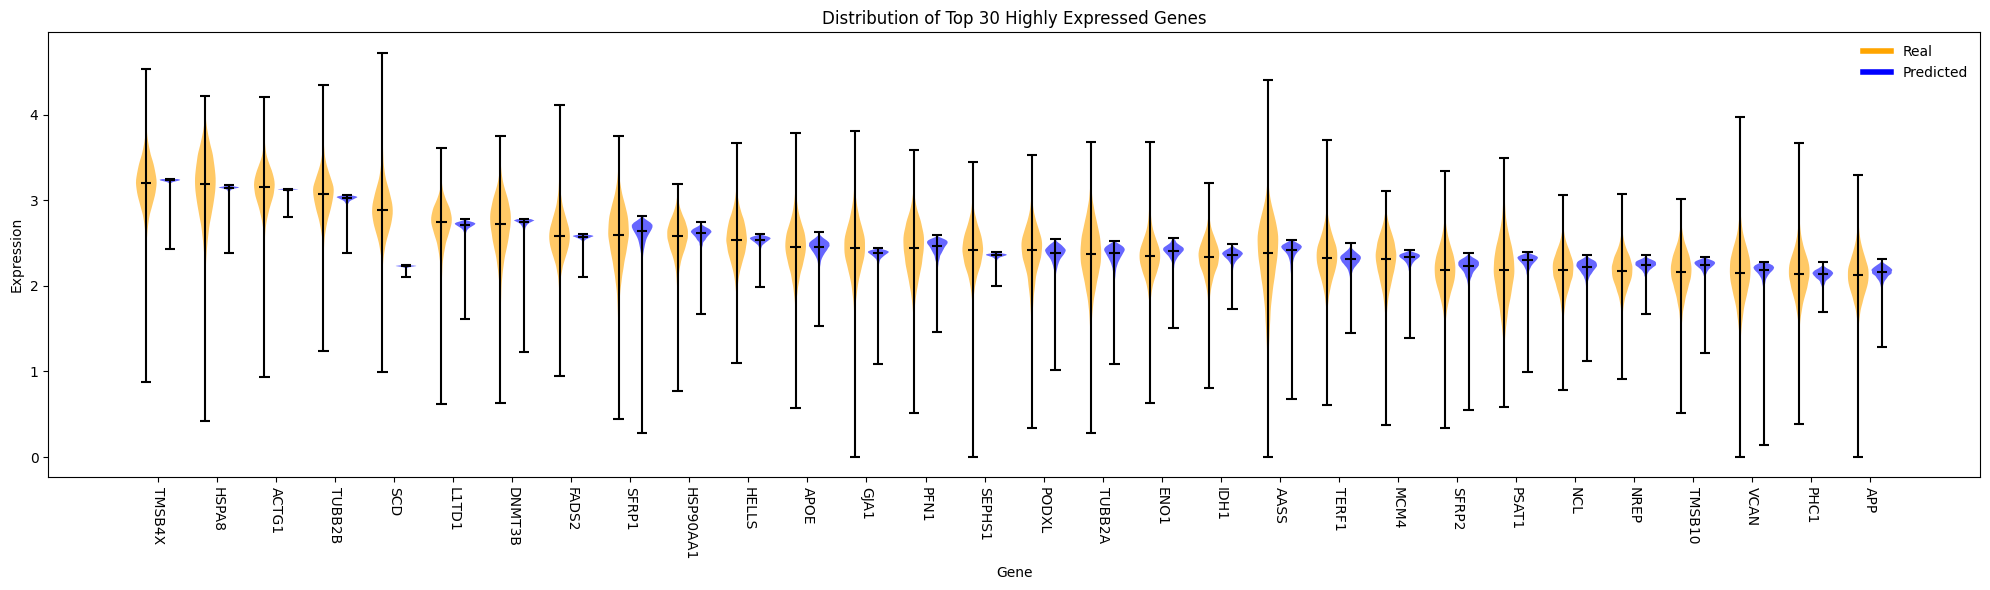

In [41]:
plot_top_highly_expressed_genes(30, real_adata[real_adata.obs['target_gene']!='non-targeting'], pred_adata[pred_adata.obs['target_gene']!='non-targeting'], False)

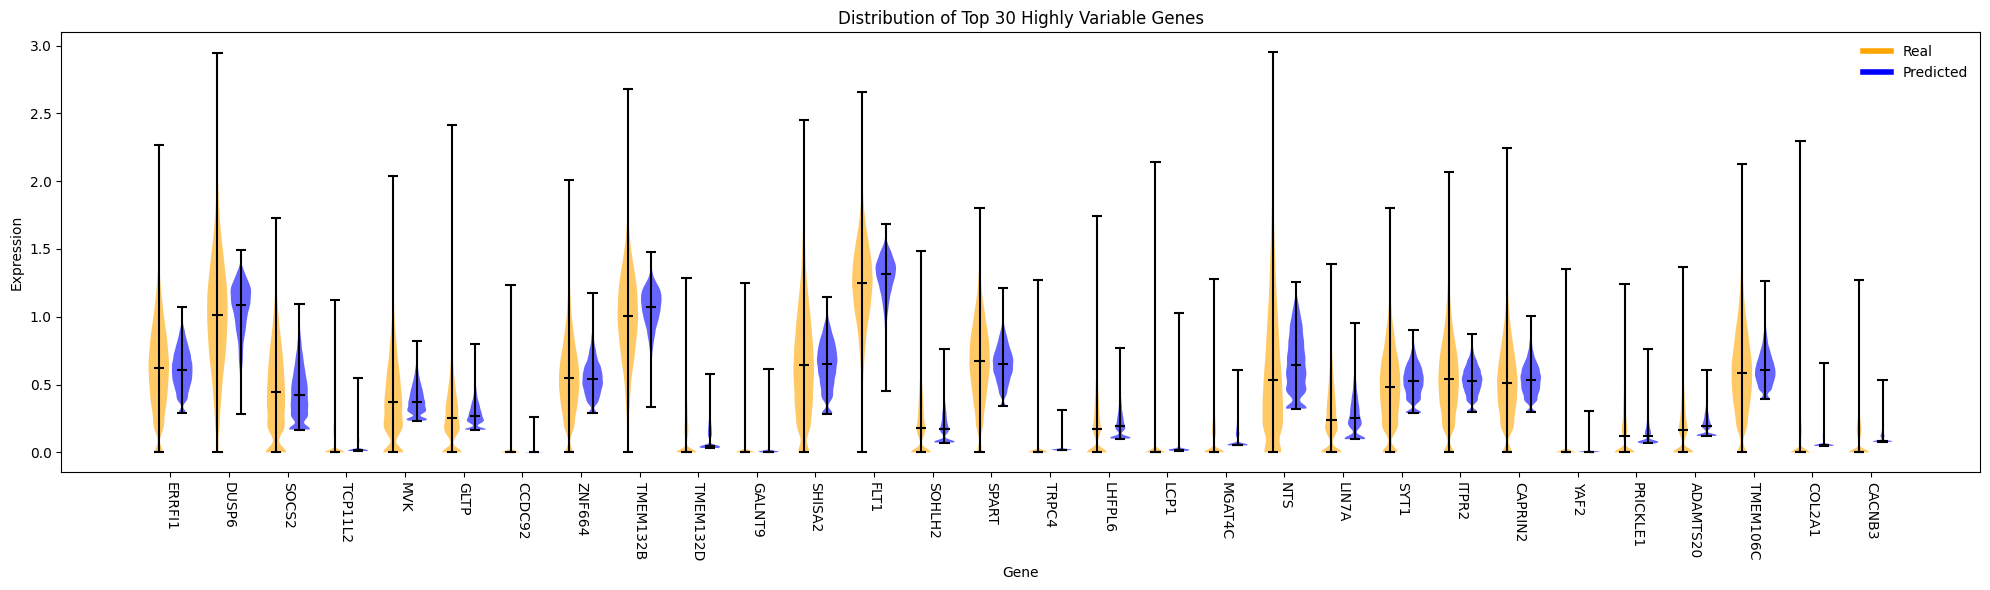

In [40]:
plot_top_highly_variable_genes(30, real_adata[real_adata.obs['target_gene']!='non-targeting'], pred_adata[pred_adata.obs['target_gene']!='non-targeting'], False)

In [32]:
pred_adata.obs['target_gene'].unique()

['PRCP', 'TADA1', 'TSC22D4', 'FOXH1', 'KLF10', ..., 'PMEL', 'KIF20A', 'SALL4', 'FDPS', 'non-targeting']
Length: 23
Categories (23, object): ['CDCA2', 'FDPS', 'FOXH1', 'HAT1', ..., 'XRCC4', 'ZNF426', 'ZNF562', 'non-targeting']

**let's try with just the DE genes**

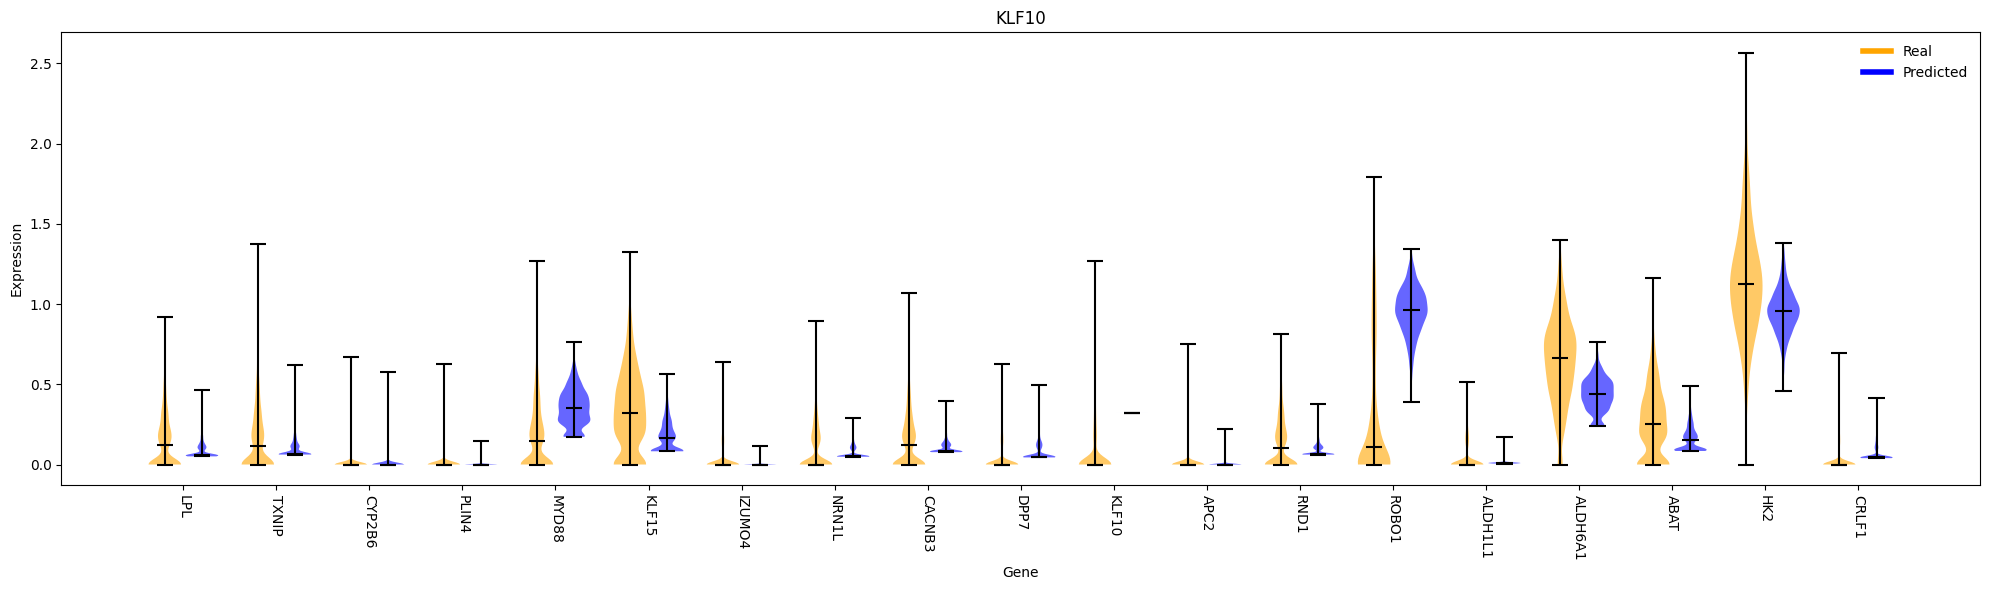

In [37]:
des_calculator = RobustDES(lfc_threshold=0.5, alpha=0.05)

max_de_genes = 20
perturb_label = 'KLF10'
DE_genes, _ = des_calculator.get_de_genes(real_adata, 'target_gene', perturb_label, 'non-targeting')
list_DE_genes = list(set(DE_genes.index))
if len(list_DE_genes)>max_de_genes:
    list_DE_genes = list(set(DE_genes.loc[DE_genes['logfoldchanges'].abs().sort_values(ascending=False).index[:max_de_genes]].index))

plot_violins_predictions_selected_genes(list_DE_genes, 
    real_adata[real_adata.obs['target_gene']==perturb_label], 
    pred_adata[pred_adata.obs['target_gene']==perturb_label], 
    False, 
    perturb_label
)